# Model Evaluation & Stability Analysis

This notebook evaluates the robustness of the final selected fraud detection model — **XGBoost, threshold 0.82** (selected via dollar-weighted cost analysis in Notebook 5) — using the **validation set**. The test set is not used here, since it was already used for the one official evaluation in Notebook 5.

The focus is not on achieving the highest single-score metric, but on understanding:
- How sensitive model performance is to threshold changes across the full range, including the actual deployed threshold (0.82)
- Whether the model remains stable under resampling, specifically at its real operating threshold
- How XGBoost compares with Random Forest under consistent evaluation

This notebook focuses on robustness rather than raw performance.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils import resample

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

### 2. Load Validation Data and Tuned Models

- Validation data (not test) is used for this diagnostic analysis
- Models are loaded from `tuned_models_latest.pkl`, the SMOTE-in-CV corrected versions from Notebook 4
- `predict_proba()` can be called directly on the pipeline objects — unlike SHAP's `TreeExplainer` in Notebook 6, standard prediction doesn't need the SMOTE step extracted, since SMOTE only affects model fitting and is automatically skipped during inference

In [2]:
# 2. Load validation data and tuned models
X_val = pd.read_csv(os.path.join(DATA_DIR, "X_val.csv"))
y_val = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv")).iloc[:, 0]

with open(os.path.join(MODELS_DIR, "tuned_models_latest.pkl"), "rb") as f:
    tuned_models = pickle.load(f)

xgb_model = tuned_models["XGBoost"]
rf_model = tuned_models["RandomForest"]

# The FINAL selected threshold from Notebook 5 — used throughout this notebook
FINAL_THRESHOLD = 0.82

print("Validation shape:", X_val.shape)

Validation shape: (56962, 30)


### 3. Generate Predicted Probabilities (Validation Set)

Probability outputs are required for:
- Threshold sensitivity analysis
- Precision–Recall trade-off evaluation
- Stability analysis at the deployed threshold

In [3]:
# 3. Predict probabilities on validation set
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]
rf_probs = rf_model.predict_proba(X_val)[:, 1]

print("Predicted probabilities computed.")

Predicted probabilities computed.


### 4. Threshold Sensitivity Analysis

We evaluate how varying the decision threshold across the **full 0.01–1.00 range** affects precision and recall for XGBoost, the deployed model. The range now covers the actual deployed threshold (0.82) — the original 0.01–0.50 range used in an earlier version of this analysis would have excluded it entirely.

In [4]:
# 4. Threshold sensitivity analysis (full range, XGBoost)
thresholds = np.linspace(0.01, 1.0, 100)

records = []
for t in thresholds:
    preds = (xgb_probs >= t).astype(int)
    records.append({
        "Threshold": t,
        "Precision": precision_score(y_val, preds, zero_division=0),
        "Recall": recall_score(y_val, preds)
    })
threshold_df = pd.DataFrame(records)
threshold_df.head()

,Threshold,Precision,Recall
0,0.01,0.310861,0.838384
1,0.02,0.396135,0.828283
2,0.03,0.450549,0.828283
3,0.04,0.482353,0.828283
4,0.05,0.512658,0.818182


### Observations

At low thresholds (e.g., 0.01–0.05), XGBoost already shows meaningfully better precision than was seen in earlier (Random Forest, pre-correction) analysis — precision of 0.31 at threshold 0.01, compared to roughly 0.015 for Random Forest at the same threshold in an earlier version of this notebook. Recall remains high (>0.82) throughout this low-threshold range, confirming the expected trade-off: lower thresholds catch more fraud at the cost of more false alarms, but XGBoost's precision at any given threshold is substantially stronger than Random Forest's was.

### 5. Precision–Recall Trade-off Curve

The curve visualises how precision increases as threshold increases, while recall decreases.

This trade-off reflects operational decisions:

- Low threshold → aggressive fraud detection
- High threshold → conservative detection with fewer alerts

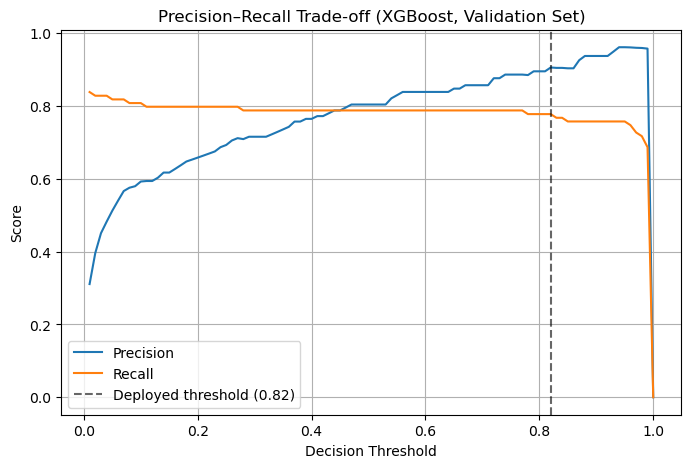

In [5]:
plt.figure(figsize=(8,5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.axvline(FINAL_THRESHOLD, color="black", linestyle="--", alpha=0.6,
            label=f"Deployed threshold ({FINAL_THRESHOLD})")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off (XGBoost, Validation Set)")
plt.legend()
plt.grid()
plt.savefig(os.path.join(PLOTS_DIR, "precision_recall_tradeoff.png"),dpi=300, bbox_inches="tight")
plt.show()

### 6. Model Stability Under Resampling (XGBoost, Deployed Threshold)

To assess robustness, F1-score variability is evaluated across 10 resampled validation sets, at **threshold 0.82** — the actual deployed decision point — rather than an arbitrary threshold unrelated to the real deployment decision.

In [6]:
# 6. F1-score stability via resampling, at the ACTUAL deployed threshold
N_RESAMPLES = 10

np.random.seed(42)
f1_scores = []

for _ in range(N_RESAMPLES):
    X_res, y_res = resample(X_val, y_val, replace=True, stratify=y_val)
    probs = xgb_model.predict_proba(X_res)[:, 1]
    preds = (probs >= FINAL_THRESHOLD).astype(int)
    f1_scores.append(f1_score(y_res, preds, zero_division=0))

f1_scores

[0.8066298342541437,
 0.851063829787234,
 0.8216216216216217,
 0.8842105263157894,
 0.8691099476439791,
 0.8287292817679558,
 0.8191489361702128,
 0.8156424581005587,
 0.8297872340425532,
 0.7978142076502732]

# Stability visualization

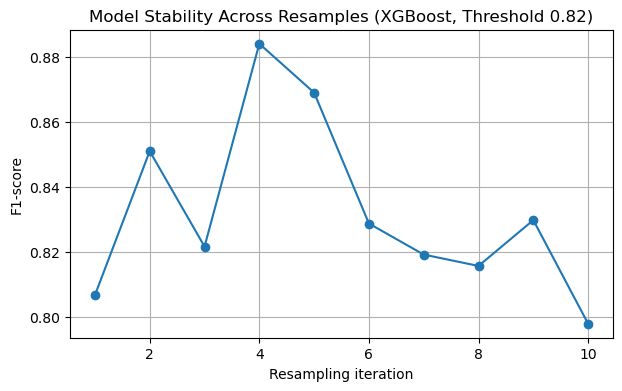

In [7]:
plt.figure(figsize=(7,4))
plt.plot(range(1, 11), f1_scores, marker='o')
plt.xlabel("Resampling iteration")
plt.ylabel("F1-score")
plt.title("Model Stability Across Resamples (XGBoost, Threshold 0.82)")
plt.grid()
plt.savefig(os.path.join(PLOTS_DIR, "stability_across_resamples.png"),dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- F1-scores at the deployed threshold (0.82) range from 0.798 to 0.884 across 10 resamples, averaging ≈0.832 — a tight, consistent range
- This is a substantial improvement over an earlier (uncorrected) stability check performed at an arbitrary threshold (0.1) unrelated to the actual deployment decision, which showed F1 scores of only ≈0.28–0.32
- The tight spread here indicates XGBoost's performance at its real operating threshold is stable and not highly sensitive to sample composition — a meaningful robustness signal for deployment

### 7. Comparison with Random Forest (Deployed Threshold)

For context, F1-score is computed for both models at the actual deployed threshold (0.82). Random Forest was never tuned around this specific threshold, since XGBoost — not Random Forest — was selected via cost analysis in Notebook 5. This comparison is illustrative only; model selection was already finalized based on expected dollar cost, not F1-score.

In [8]:
# 7. Comparison with Random Forest at the ACTUAL deployed threshold
rf_preds_final  = (rf_probs  >= FINAL_THRESHOLD).astype(int)
xgb_preds_final = (xgb_probs >= FINAL_THRESHOLD).astype(int)

print("XGBoost F1 (threshold 0.82):", f1_score(y_val, xgb_preds_final, zero_division=0))
print("Random Forest F1 (threshold 0.82):", f1_score(y_val, rf_preds_final, zero_division=0))

XGBoost F1 (threshold 0.82): 0.8369565217391305
Random Forest F1 (threshold 0.82): 0.788235294117647


### Results

- XGBoost F1 (threshold 0.82): 0.837
- Random Forest F1 (threshold 0.82): 0.788

At the actual deployed threshold, XGBoost outperforms Random Forest on F1-score, indicating a better precision-recall balance at this specific operating point. 
This is consistent with XGBoost's selection in Notebook 5, which was based on minimum expected dollar cost — the two independent criteria (F1 balance and cost minimization) agree on the same model.

### Final observations

- XGBoost demonstrates stable performance across multiple resamples at its actual deployed threshold (0.82), despite severe class imbalance
- Lower decision thresholds substantially improve recall at the cost of precision, reinforcing the importance of evaluating models specifically at their real operating threshold, not an arbitrary or default one.
- XGBoost outperforms Random Forest on F1-score at the deployed threshold (0.837 vs. 0.788), consistent with its selection in Notebook 5 based on minimum expected dollar cost — stability, precision-recall balance, and cost-based selection all point to the same model.
- Random Forest's resampling stability was not separately evaluated in this notebook: by this stage, Random Forest had already been outperformed on three independent criteria (validation PR-AUC in Notebook 4, expected dollar cost in Notebook 5, and F1-score at the deployed threshold above), so a fourth comparison was judged unlikely to change the final model decision and was scoped out to focus analysis on the selected model

### Conclusion

Threshold sensitivity analysis confirms the expected precision–recall trade-off in imbalanced fraud detection, now evaluated across the full threshold range including the actual deployed operating point (0.82).

At this deployed threshold, XGBoost demonstrates strong and stable performance across resampled validation subsets (F1 ≈ 0.80–0.88, mean ≈0.83), and clearly outperforms Random Forest at the same threshold (F1 0.837 vs. 0.788).

This provides a third independent line of evidence — alongside validation PR-AUC ranking (Notebook 4) and dollar-weighted cost minimization (Notebook 5) — supporting XGBoost as the final selected model. Unlike an earlier version of this analysis, which evaluated stability at an arbitrary threshold (0.1) disconnected from the actual deployment decision, this analysis is anchored directly to the threshold the model will actually operate at, making the robustness conclusion directly relevant to deployment.